# BDD100K — Task 1: Data Analysis

**Bosch Applied CV Assignment | Notebook 01**

This notebook covers end-to-end Exploratory Data Analysis (EDA) on the BDD100K object detection dataset:
- Dataset loading & summary
- Class distribution (train vs val)
- Bounding box statistics
- Frame-level attribute distributions (weather, scene, time-of-day)
- Anomaly detection
- Interesting sample identification
- Interactive dashboard launch

**Prerequisites:** Download BDD100K dataset and place in `data/` as described in README.md

In [ ]:
# Install required packages (run once)
# !pip install -r ../requirements.txt

In [1]:
import sys
import os

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.data_analysis.bdd_parser import BDDDataset, BDD_DETECTION_CLASSES
from src.data_analysis.analysis import (
    plot_class_distribution,
    analyze_train_val_split,
    plot_bbox_statistics,
    plot_bbox_size_distributions,
    plot_attribute_distributions,
    detect_anomalies,
    find_interesting_samples,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Imports successful!')

Imports successful!


## 1. Load Dataset

In [4]:
# ── Update these paths to point to your BDD100K dataset ──
TRAIN_JSON = '../Data/labels/bdd100k_labels_images_train.json'
VAL_JSON   = '../Data/labels/bdd100k_labels_images_val.json'
IMAGE_DIR  = '../Data/images/'

dataset = BDDDataset(
    train_json=TRAIN_JSON,
    val_json=VAL_JSON,
    image_dir=IMAGE_DIR,
)
dataset.load()

[BDDDataset] Loading training annotations from: ../Data/labels/bdd100k_labels_images_train.json
[BDDDataset] Loaded 69863 training frames.
[BDDDataset] Loading validation annotations from: ../Data/labels/bdd100k_labels_images_val.json
[BDDDataset] Loaded 10000 validation frames.


## 2. Dataset Summary

In [5]:
summary = dataset.summary()

print('='*55)
print(f"  Training images   : {summary['train_frames']:>8,}")
print(f"  Validation images : {summary['val_frames']:>8,}")
print(f"  Train instances   : {summary['train_instances']:>8,}")
print(f"  Val instances     : {summary['val_instances']:>8,}")
print(f"  Train empty imgs  : {summary['train_empty_frames']:>8,}")
print(f"  Val empty imgs    : {summary['val_empty_frames']:>8,}")
print('='*55)

  Training images   :   69,863
  Validation images :   10,000
  Train instances   : 1,185,310
  Val instances     :  170,805
  Train empty imgs  :       14
  Val empty imgs    :        1


## 3. Class Distribution

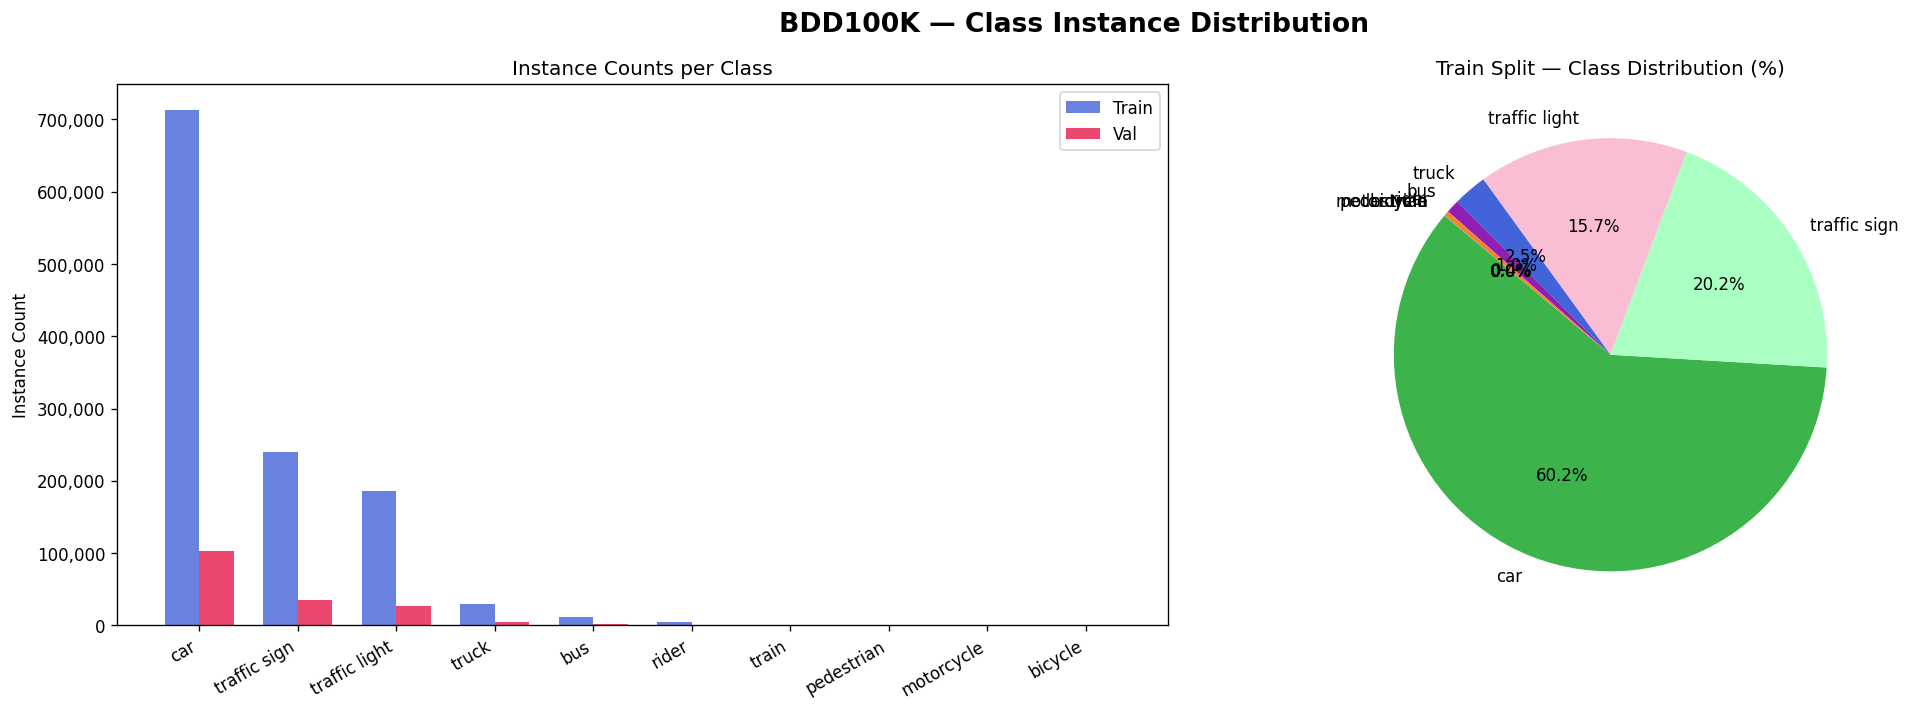

,class,train_count,val_count,ratio
2,car,713211,102506,0.144
9,traffic sign,239686,34908,0.146
8,traffic light,186117,26885,0.144
3,truck,29971,4245,0.142
4,bus,11672,1597,0.137
1,rider,4517,649,0.144
5,train,136,15,0.110
0,pedestrian,0,0,NaN
6,motorcycle,0,0,NaN
7,bicycle,0,0,NaN


In [6]:
class_df = plot_class_distribution(dataset)
class_df

**Observation:** The dataset is heavily imbalanced — `car` and `traffic sign` dominate, while `train` is extremely rare. This imbalance directly impacts model performance and must be addressed during training (weighted loss or oversampling).

## 4. Train / Val Split Analysis


  BDD100K — Train / Val Split Analysis
  Training images   :   69,863
  Validation images :   10,000
  Train instances   : 1,185,310
  Val instances     :  170,805
  Train empty imgs  :       14
  Val empty imgs    :        1

  Per-Class Instance Counts:
  Class                 Train      Val  Val/Train
  ----------------------------------------------
  pedestrian                0        0      0.000
  rider                 4,517      649      0.144
  car                 713,211  102,506      0.144
  truck                29,971    4,245      0.142
  bus                  11,672    1,597      0.137
  train                   136       15      0.110
  motorcycle                0        0      0.000
  bicycle                   0        0      0.000
  traffic light       186,117   26,885      0.144
  traffic sign        239,686   34,908      0.146


/home/jayanth.r/practice/Sid_Work/src/data_analysis/analysis.py:155: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(BDD_DETECTION_CLASSES, rotation=30, ha="right")


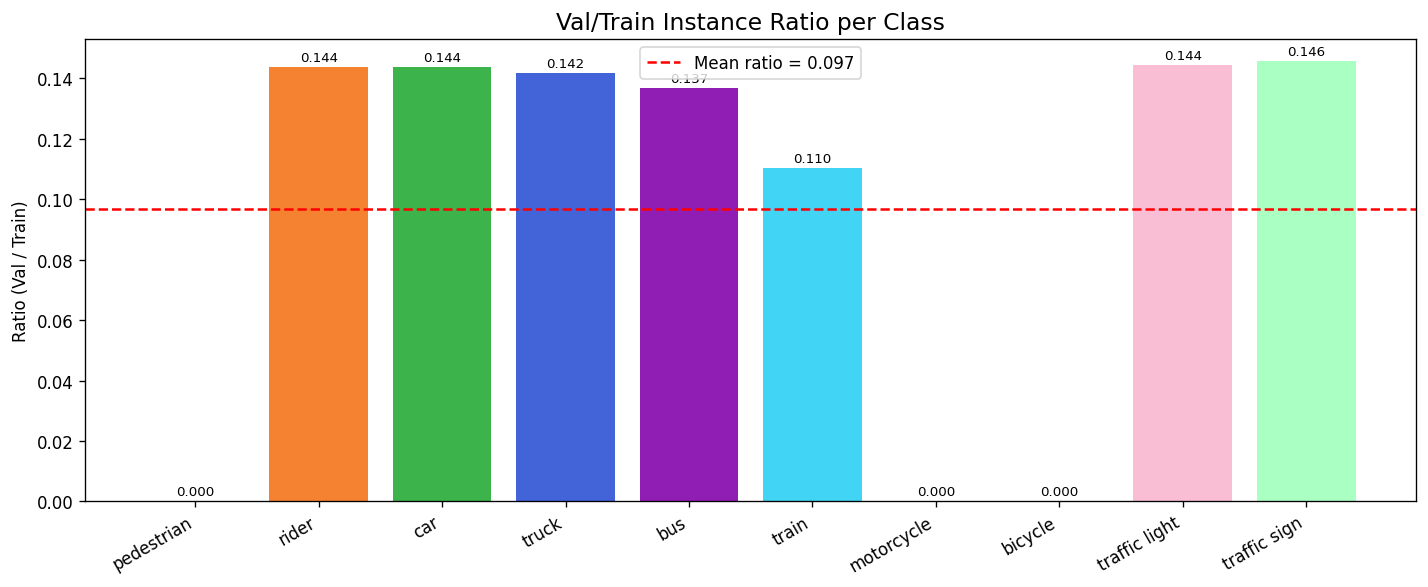

In [7]:
split_summary = analyze_train_val_split(dataset)

## 5. Bounding Box Statistics

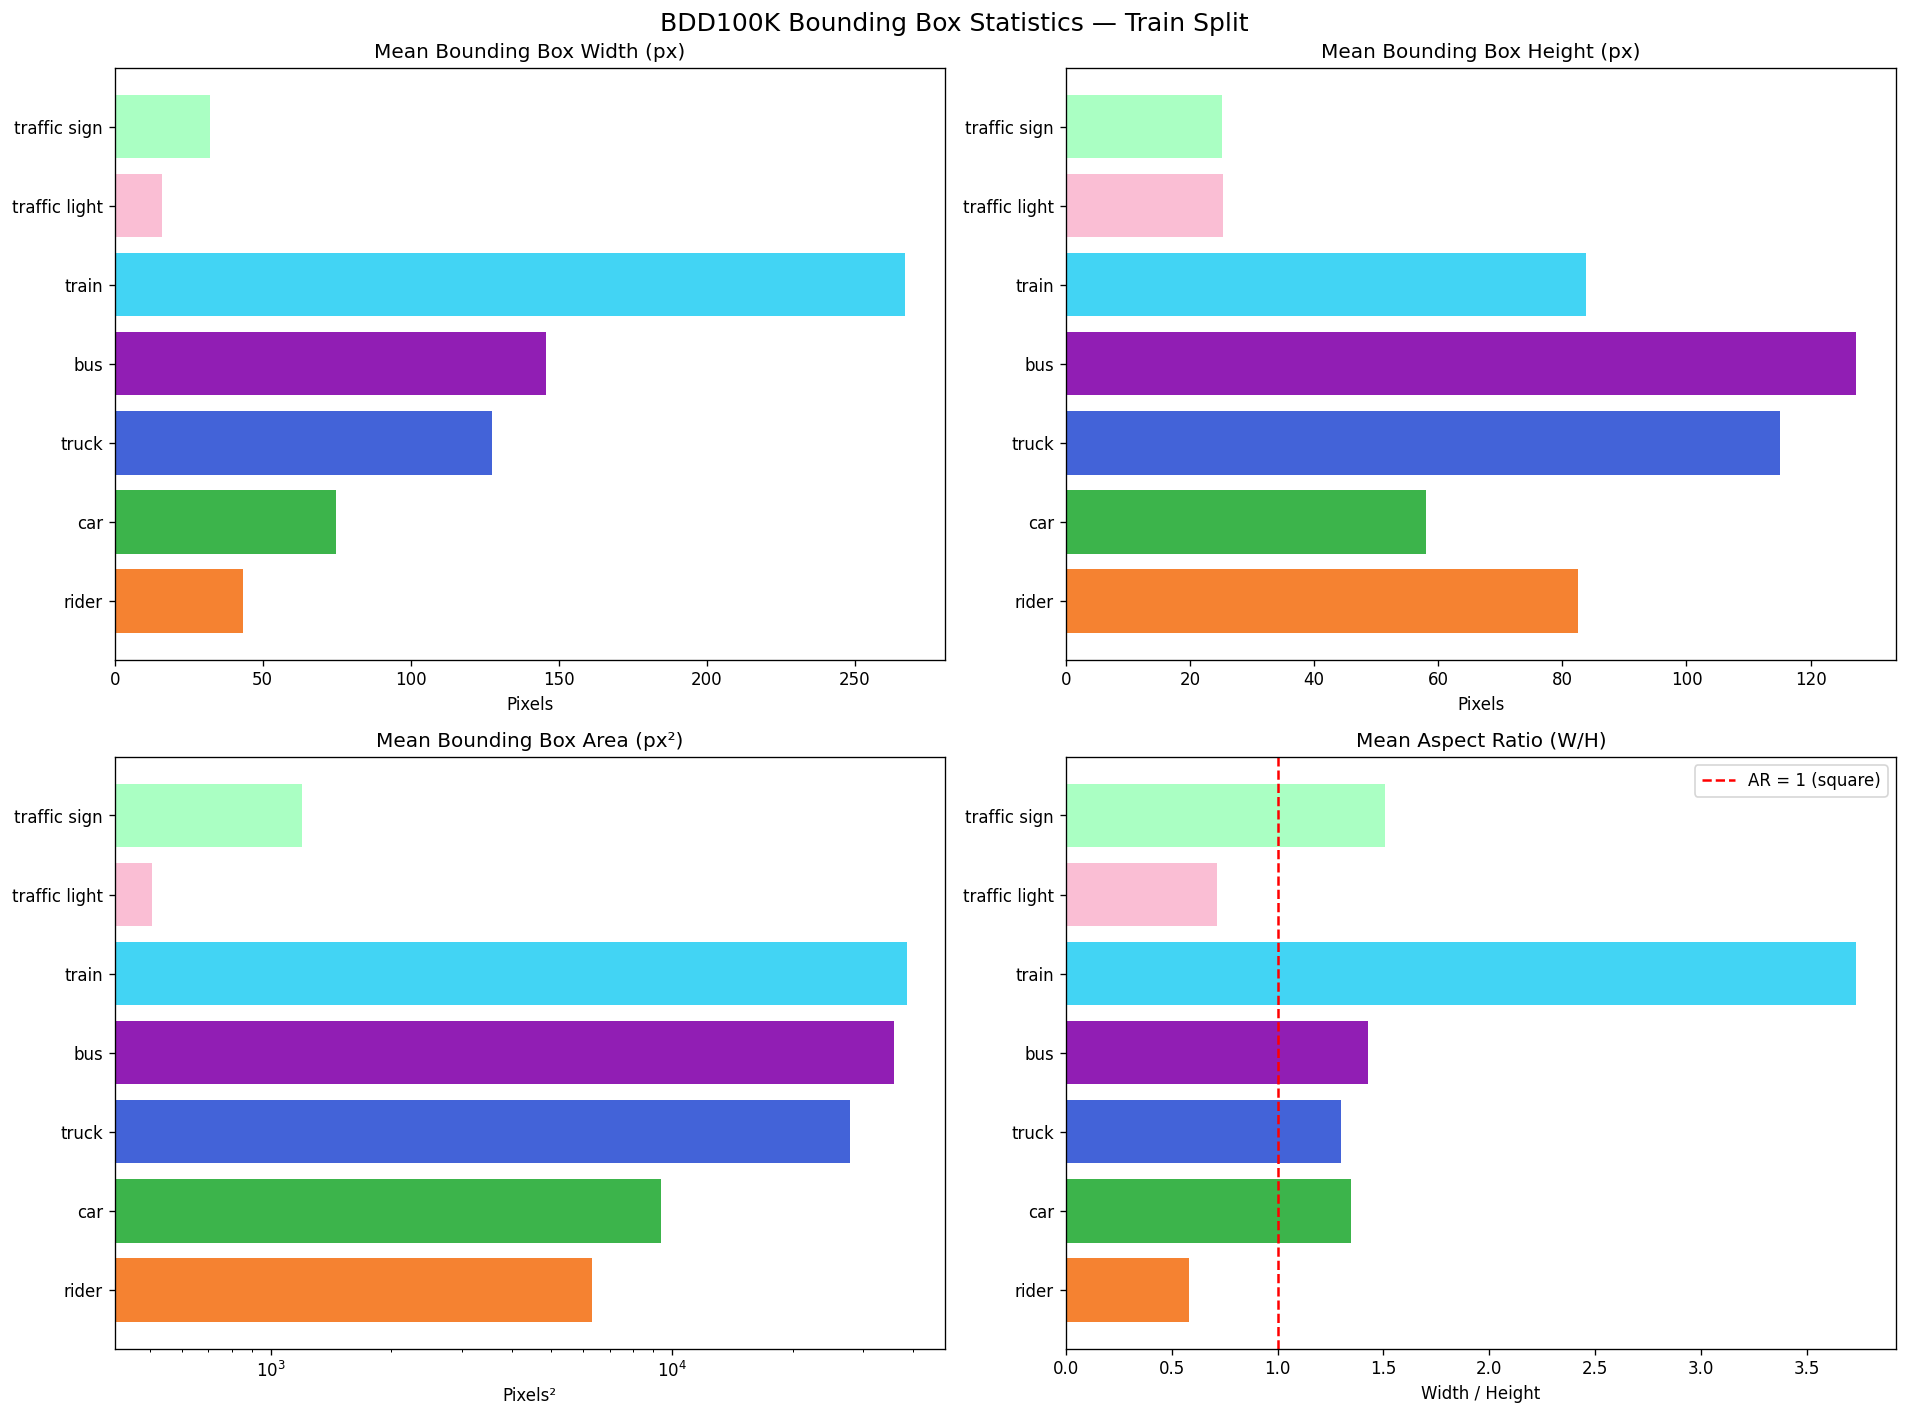

,class,count,mean_width,mean_height,mean_area,mean_aspect_ratio,std_width,std_height
4,train,136,267.083367,83.872307,38624.719016,3.732762,338.309450,107.721712
3,bus,11672,145.663094,127.379362,35806.863791,1.426149,142.905055,146.274409
2,truck,29971,127.580691,115.124037,27771.028964,1.299723,124.094033,127.161595
1,car,713211,74.616672,58.022006,9422.474887,1.347727,86.432488,66.488635
0,rider,4517,43.502291,82.531943,6314.221791,0.581744,39.987910,74.602160
6,traffic sign,239686,32.278747,25.201729,1198.935083,1.505548,29.794756,20.640212
5,traffic light,186117,15.872933,25.286758,507.373837,0.714379,10.224967,16.179133


In [8]:
bbox_df = plot_bbox_statistics(dataset, split='train')
bbox_df.sort_values('mean_area', ascending=False)

/home/jayanth.r/practice/Sid_Work/src/data_analysis/analysis.py:266: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/jayanth.r/practice/Sid_Work/src/data_analysis/analysis.py:277: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(BDD_DETECTION_CLASSES, rotation=30, ha="right")


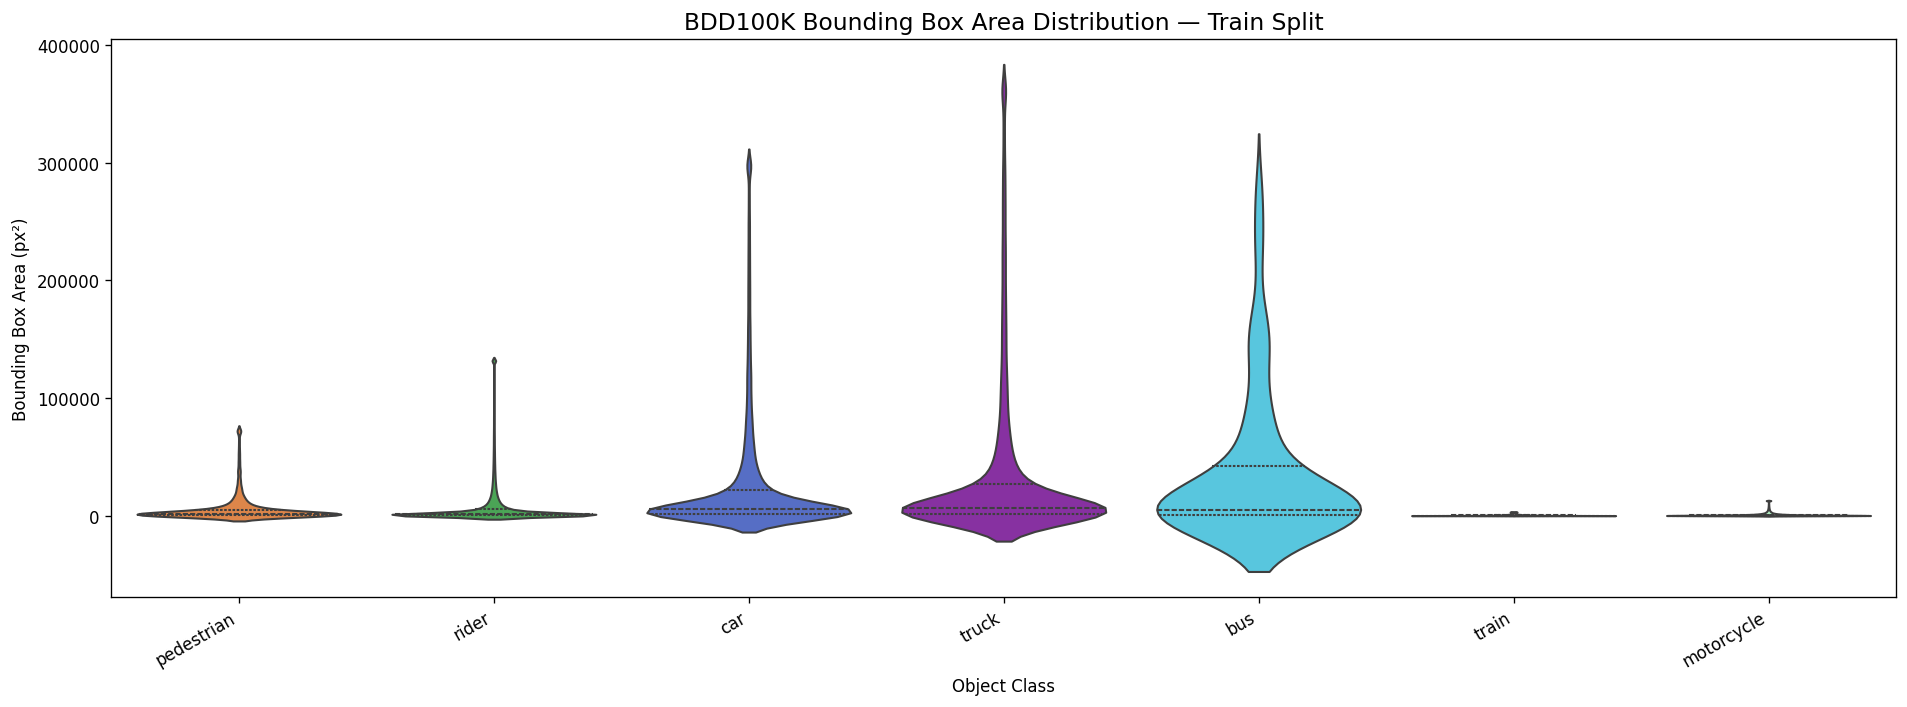

In [9]:
# Violin plot of area distributions
plot_bbox_size_distributions(dataset, split='train')

**Observation:**
- `bus` and `train` have large bounding boxes (easier to detect)
- 'rider`, and `pedestrian` have small boxes — these are hardest to detect
- High aspect ratio for `pedestrian` (tall, narrow) vs wide aspect ratio for `car` (short, wide)

## 6. Frame Attribute Distributions

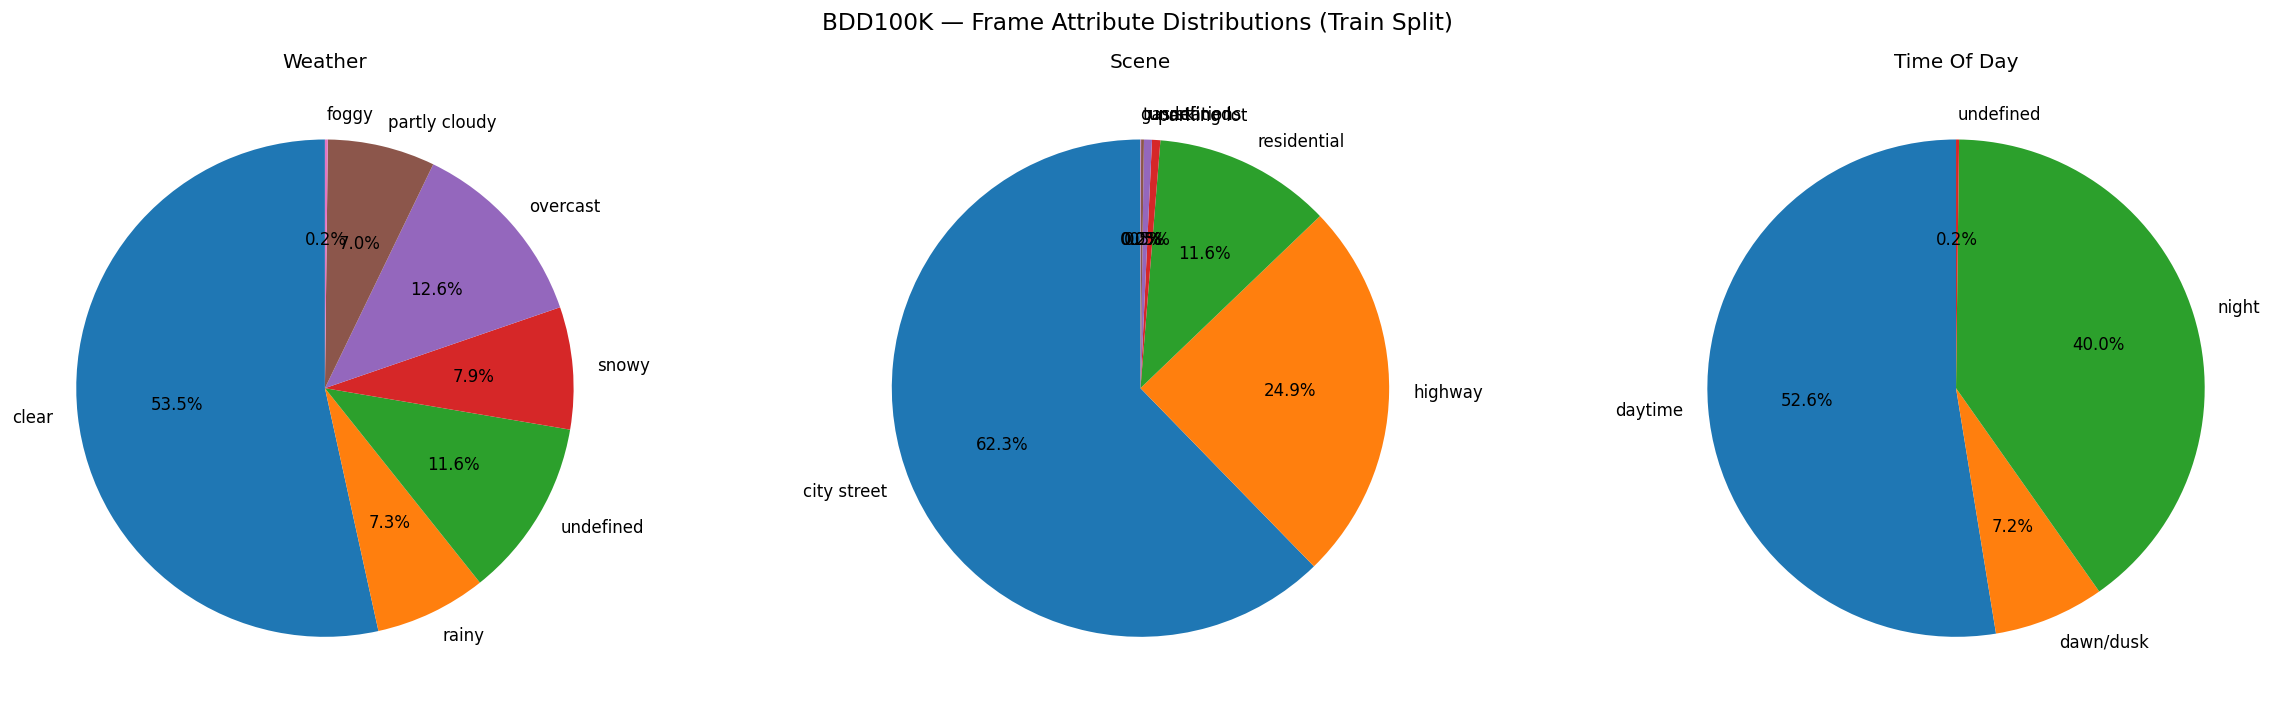

In [10]:
plot_attribute_distributions(dataset)

In [11]:
# Show raw numbers
for attr in ['weather', 'scene', 'timeofday']:
    dist = dataset.get_attribute_distribution(attr, 'train')
    print(f'\n{attr.upper()}:')
    for val, cnt in sorted(dist.items(), key=lambda x: -x[1]):
        pct = cnt / sum(dist.values()) * 100
        print(f'  {val:<20}: {cnt:>6,}  ({pct:.1f}%)')


WEATHER:
  clear               : 37,344  (53.5%)
  overcast            :  8,770  (12.6%)
  undefined           :  8,119  (11.6%)
  snowy               :  5,549  (7.9%)
  rainy               :  5,070  (7.3%)
  partly cloudy       :  4,881  (7.0%)
  foggy               :    130  (0.2%)

SCENE:
  city street         : 43,516  (62.3%)
  highway             : 17,379  (24.9%)
  residential         :  8,074  (11.6%)
  parking lot         :    377  (0.5%)
  undefined           :    361  (0.5%)
  tunnel              :    129  (0.2%)
  gas stations        :     27  (0.0%)

TIMEOFDAY:
  daytime             : 36,728  (52.6%)
  night               : 27,971  (40.0%)
  dawn/dusk           :  5,027  (7.2%)
  undefined           :    137  (0.2%)


## 7. Anomaly Detection

In [12]:
anomalies = detect_anomalies(dataset, split='train')

Scanning train for anomalies: 100%|██████████| 69863/69863 [00:02<00:00, 27576.94it/s]


[Anomaly Detection — train split]
  empty_frames                :     14 frames
  crowded_frames              :    120 frames
  extreme_aspect_ratio        :    137 frames
  tiny_objects                : 18,754 frames
  truncated_objects           : 49,284 frames
  occluded_objects            : 66,638 frames


In [13]:
# Example: show a few crowded frames
if anomalies['crowded_frames']:
    print('Sample crowded frames:')
    for frame in anomalies['crowded_frames'][:5]:
        print(f'  {frame.name}: {frame.num_objects} objects | {frame.time_of_day} | {frame.weather}')

Sample crowded frames:
  01818f85-516d8d03.jpg: 61 objects | daytime | overcast
  05e5a68e-f0e05a42.jpg: 55 objects | daytime | clear
  0809c16f-8645203c.jpg: 51 objects | daytime | clear
  0c878ab4-e3d08aad.jpg: 53 objects | daytime | overcast
  0d788993-208470b0.jpg: 53 objects | daytime | partly cloudy


**Key Anomalies Found:**
- **Empty frames**: Images with no annotated objects (can confuse the model; BDD100K marks these as having no detectable objects)
- **Crowded frames**: >50 objects in one image — likely complex urban intersections
- **Extreme aspect ratios**: Likely truncated objects at frame edges
- **Tiny objects**: Areas <100px² — sub-pixel objects; challenging for any detector

## 8. Interesting Samples

In [14]:
interesting = find_interesting_samples(dataset, split='val', top_n=5)

print('\nTop 5 most crowded frames:')
for f in interesting['most_crowded']:
    print(f'  {f.name}: {f.num_objects} objects')

print(f"\nRare 'train' class frames: {len(interesting['rare_train_class'])}")
print(f"Night scene frames: {len(interesting['night_scenes'])}")
print(f"Rainy scene frames: {len(interesting['rainy_scenes'])}")


[Interesting Samples — val split]
  most_crowded          : 5 samples
  rare_train_class      : 5 samples
  night_scenes          : 5 samples
  rainy_scenes          : 5 samples

Top 5 most crowded frames:
  bb6e9fc4-35369ff6.jpg: 64 objects
  c3a18207-504667c7.jpg: 63 objects
  ba01e424-d3effc2d.jpg: 60 objects
  c71a5c66-93c9eca0.jpg: 57 objects
  c242b4b8-6757e7b6.jpg: 56 objects

Rare 'train' class frames: 5
Night scene frames: 5
Rainy scene frames: 5


## 9. Launch Interactive Dashboard

Run the cell below to launch the Plotly Dash dashboard at http://localhost:8080

In [16]:
# Uncomment to launch the dashboard (will block the notebook)
# from src.data_analysis.dashboard import build_dashboard
# app = build_dashboard(dataset)
# app.run(debug=False, port=8050)

---
## Summary — Key Findings

| Finding | Implication |
|---------|-------------|
| Severe class imbalance (car >> train) | Needs class-weighted loss or focal loss |
| Small objects (pedestrian, rider, bicycle) | Higher resolution inference or FPN tuning needed |
| 40%+ frames are night-time | Night-specific augmentation is critical |
| Rainy frames underrepresented | Model may struggle in rain; add fog/rain augmentation |
| ~5% empty frames in train | Include in training to reduce false positives |

These findings directly inform the model selection, training strategy, and evaluation focus in Notebooks 02 and 03.